# 01 · Data Exploration
**Big Data–Driven Intelligent Disease Surveillance & Early Outbreak Detection (Nigeria)**

Exploratory analysis of weekly surveillance data for the four target diseases —
**Lassa fever, cholera, cerebrospinal meningitis (CSM), and mpox** — covering
2015–2024 across Nigeria's 36 states + FCT. We examine dataset structure, data
quality / missing values, temporal trends, seasonality, geographic burden, and
the labelled outbreak weeks that serve as ground truth for anomaly detection.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)

DATA = Path("../backend/data")
DISEASES = ["lassa", "cholera", "meningitis", "mpox"]
LABELS = {"lassa": "Lassa fever", "cholera": "Cholera",
          "meningitis": "Meningitis (CSM)", "mpox": "Mpox"}


def load(disease: str) -> pd.DataFrame:
    df = pd.read_csv(DATA / f"ncdc_{disease}.csv", parse_dates=["date"])
    df["disease"] = disease
    return df


cases = pd.concat([load(d) for d in DISEASES], ignore_index=True)
print("Combined shape:", cases.shape)
cases.head()

Combined shape: (73112, 10)


,date,year,week,state,suspected,confirmed,deaths,cfr,is_outbreak,disease
0,2014-12-29,2015,1,Jigawa,4,3,1,0.3333,0,lassa
1,2014-12-29,2015,1,Kaduna,1,0,0,0.0000,0,lassa
2,2014-12-29,2015,1,Kano,3,0,0,0.0000,0,lassa
3,2014-12-29,2015,1,Katsina,1,0,0,0.0000,0,lassa
4,2014-12-29,2015,1,Kebbi,3,2,1,0.5000,0,lassa


## Dataset overview
Each row is one (disease, state, ISO-week) observation.

In [2]:
for d in DISEASES:
    sub = cases[cases.disease == d]
    print(f"{LABELS[d]:18s} rows={len(sub):6d}  "
          f"{sub.date.min().date()} -> {sub.date.max().date()}  "
          f"states={sub.state.nunique()}")

Lassa fever        rows= 19240  2014-12-29 -> 2024-12-23  states=37
Cholera            rows= 19240  2014-12-29 -> 2024-12-23  states=37
Meningitis (CSM)   rows= 19240  2014-12-29 -> 2024-12-23  states=37
Mpox               rows= 15392  2017-01-02 -> 2024-12-23  states=37


## Data quality — missing values & range checks
Real NCDC data carries gaps and inconsistent case definitions; here we confirm
completeness and that the case hierarchy (deaths ≤ confirmed ≤ suspected) holds.

In [3]:
print("Missing values per column:")
print(cases.isnull().sum())
print("\nIntegrity checks (counts of violations, expect 0):")
print("  suspected < 0       :", int((cases.suspected < 0).sum()))
print("  confirmed > suspected:", int((cases.confirmed > cases.suspected).sum()))
print("  deaths > confirmed  :", int((cases.deaths > cases.confirmed).sum()))

Missing values per column:
date           0
year           0
week           0
state          0
suspected      0
confirmed      0
deaths         0
cfr            0
is_outbreak    0
disease        0
dtype: int64

Integrity checks (counts of violations, expect 0):
  suspected < 0       : 0
  confirmed > suspected: 0
  deaths > confirmed  : 0


## Burden summary by disease
Totals over the full period, with the case-fatality rate (CFR).

In [4]:
summary = (cases.groupby("disease")
           .agg(suspected=("suspected", "sum"),
                confirmed=("confirmed", "sum"),
                deaths=("deaths", "sum"))
           .reindex(DISEASES))
summary["CFR_%"] = (100 * summary.deaths / summary.confirmed).round(1)
summary.index = [LABELS[d] for d in summary.index]
summary

,suspected,confirmed,deaths,CFR_%
Lassa fever,62577,13925,2537,18.2
Cholera,157795,70925,2314,3.3
Meningitis (CSM),46877,8549,771,9.0
Mpox,15918,6102,156,2.6


## National weekly trend (2015–2024)
Confirmed cases per epidemiological week, summed across all states. Outbreak
years stand out clearly — e.g. the 2021 cholera epidemic and the 2022 mpox surge.

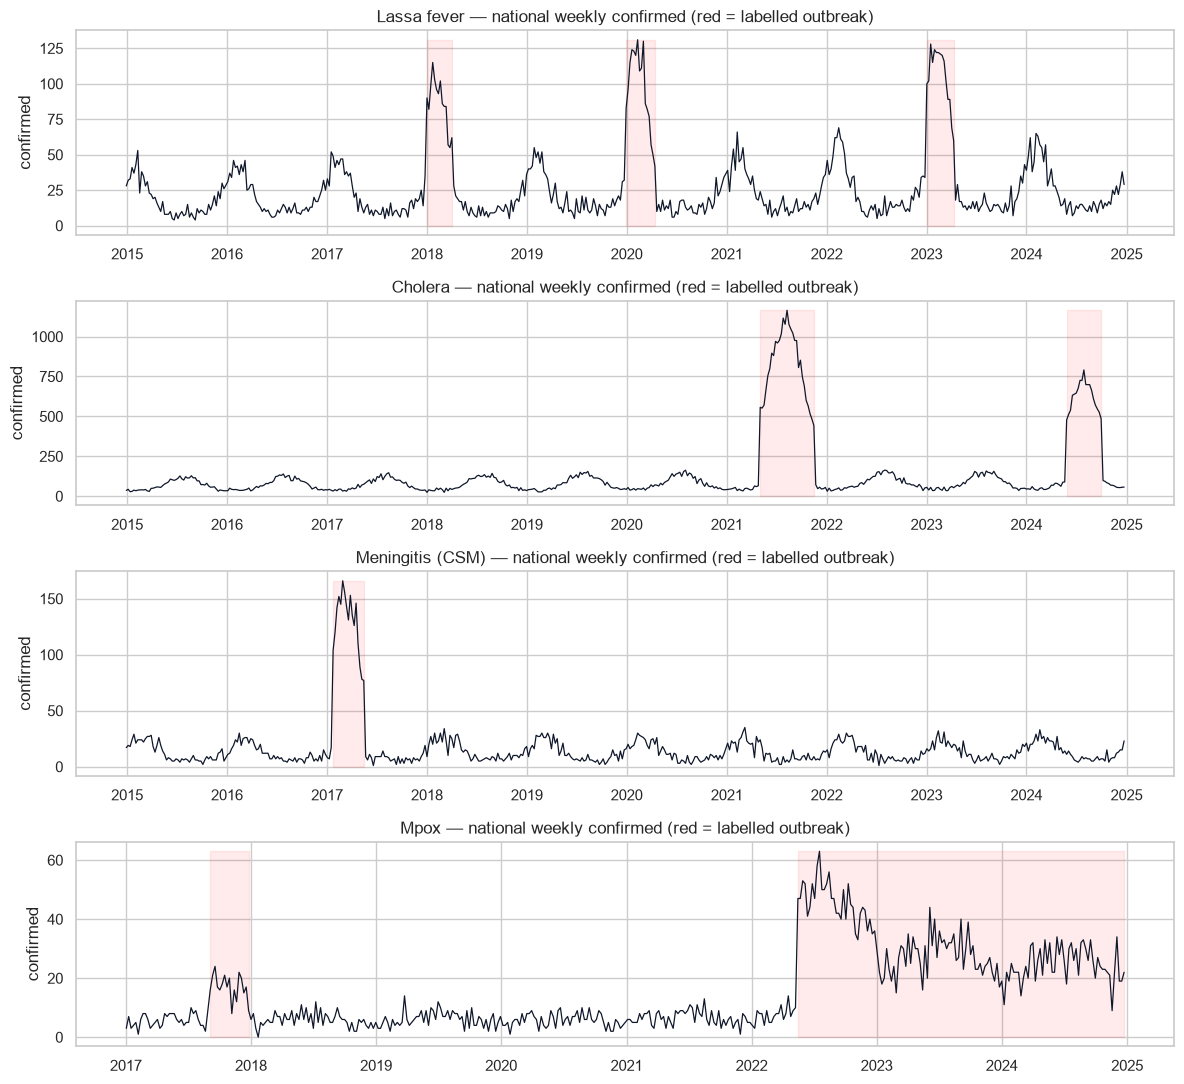

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(12, 11))
for ax, d in zip(axes, DISEASES):
    ts = (cases[cases.disease == d].groupby("date")
          .agg(confirmed=("confirmed", "sum"), outbreak=("is_outbreak", "max")))
    ax.plot(ts.index, ts.confirmed, lw=0.9, color="#0f172a")
    ax.fill_between(ts.index, 0, ts.confirmed.max(),
                    where=ts.outbreak.astype(bool), color="red", alpha=0.08, step="mid")
    ax.set_title(f"{LABELS[d]} — national weekly confirmed (red = labelled outbreak)")
    ax.set_ylabel("confirmed")
plt.tight_layout()
plt.savefig("figures/national_trends.png", dpi=110, bbox_inches="tight")
plt.show()

## Seasonality
Mean weekly confirmed by ISO week (normalised per disease) reveals each
disease's seasonal signature: Lassa and meningitis peak in the dry season,
cholera in the rains.

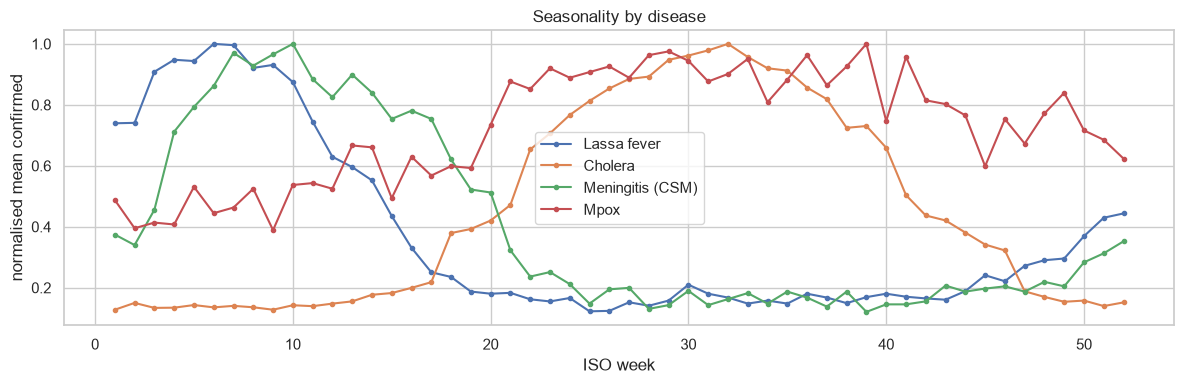

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
for d in DISEASES:
    wk = cases[cases.disease == d].groupby("week").confirmed.mean()
    ax.plot(wk.index, wk / wk.max(), marker="o", ms=3, label=LABELS[d])
ax.set(xlabel="ISO week", ylabel="normalised mean confirmed",
       title="Seasonality by disease")
ax.legend()
plt.tight_layout()
plt.savefig("figures/seasonality.png", dpi=110, bbox_inches="tight")
plt.show()

## Geographic burden — Lassa fever, top 10 states

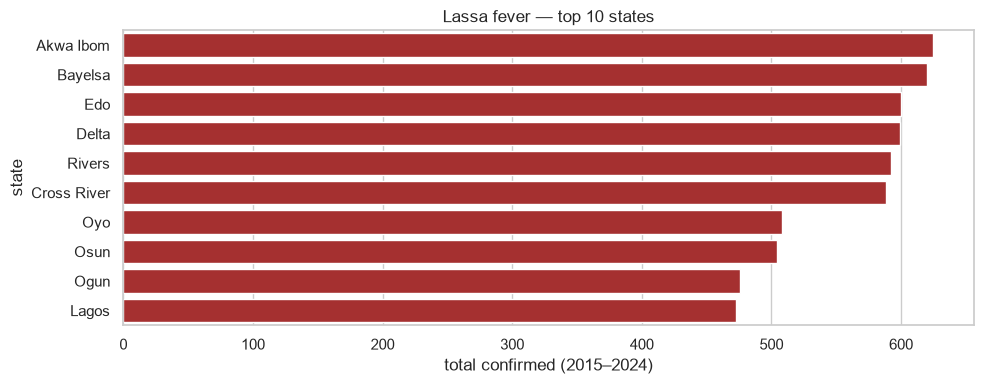

In [7]:
top = (cases[cases.disease == "lassa"].groupby("state").confirmed.sum()
       .sort_values(ascending=False).head(10))
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=top.values, y=top.index, ax=ax, color="#b91c1c")
ax.set(xlabel="total confirmed (2015–2024)", title="Lassa fever — top 10 states")
plt.tight_layout()
plt.show()

## Weather alignment (cholera vs rainfall)
Open-Meteo weekly rainfall, overlaid on cholera incidence, to motivate weather
as an exogenous feature for the forecaster.

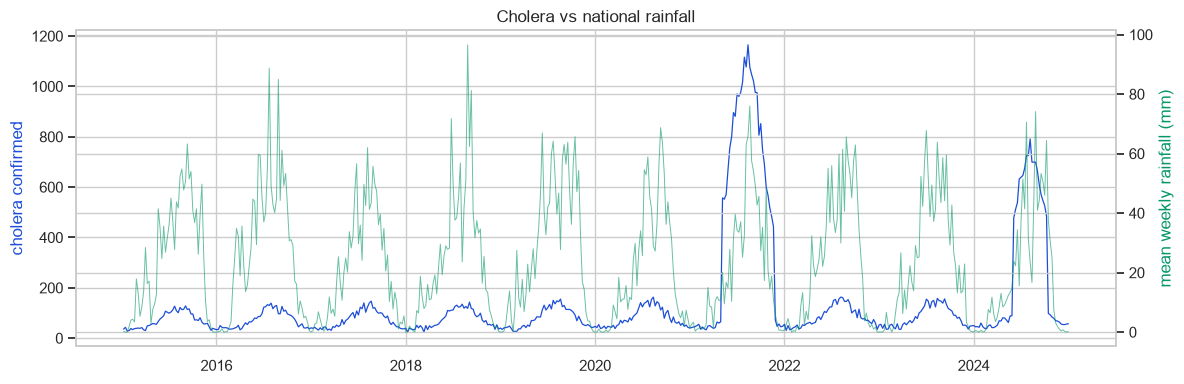

Correlation (cholera confirmed vs rainfall): 0.349


In [8]:
wpath = DATA / "weather.csv"
if wpath.exists():
    w = pd.read_csv(wpath)
    nat_rain = w.groupby(["year", "week"]).rainfall_sum.mean().reset_index()
    chol = (cases[cases.disease == "cholera"].groupby(["year", "week"])
            .confirmed.sum().reset_index())
    m = chol.merge(nat_rain, on=["year", "week"])
    m["t"] = m.year + m.week / 52
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(m.t, m.confirmed, color="#1d4ed8", lw=0.9)
    ax1.set_ylabel("cholera confirmed", color="#1d4ed8")
    ax2 = ax1.twinx()
    ax2.plot(m.t, m.rainfall_sum, color="#059669", lw=0.7, alpha=0.6)
    ax2.set_ylabel("mean weekly rainfall (mm)", color="#059669")
    ax1.set_title("Cholera vs national rainfall")
    plt.tight_layout()
    plt.show()
    print("Correlation (cholera confirmed vs rainfall):",
          round(m.confirmed.corr(m.rainfall_sum), 3))
else:
    print("weather.csv not present yet — run backend/scripts/fetch_weather.py")

### Takeaways
- Series are complete (no missing weeks) with a valid case hierarchy.
- Outbreak years are visually distinct → strong signal for anomaly detection.
- Pronounced, disease-specific seasonality → week-of-year is a key feature.
- Cholera tracks rainfall → justifies weather as an exogenous LSTM input.

**Next:** `02 · Data preprocessing` — cleaning, normalisation, feature
engineering (lags, week-of-year, weather), and the train/val/test split.